# 01_data_preparation

This notebook prepares the brain MRI dataset for Xception-based
four-class tumor classification.

Classes:
- Glioma
- Meningioma
- No Tumor
- Pituitary

# 1. Import Needed Libraries

In [ ]:
from pathlib import Path
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf

# 2. Reproducibility Configuration

In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 3. Path Configuration

In [7]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# 4. Dataset Structure & Sample Distribution

In [8]:
import kagglehub

dataset_path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Dataset path:", dataset_path)

Dataset path: /home/mehr/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2


In [9]:
CLASS_NAMES = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary",
]

In [10]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}

def build_dataframe(data_dir: str | Path) -> pd.DataFrame:
    data_dir = Path(data_dir)
    records = []
    
    for class_dir in sorted(data_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        
        for image_path in sorted(class_dir.iterdir()):
            if image_path.is_file() and image_path.suffix.lower() in VALID_EXTENSIONS:
                records.append(
                    {
                        "filepath": str(image_path),
                        "label": class_dir.name,
                    }
                )
    if not records:
        raise ValueError(f"No image files were found in: {data_dir}")
    
    return pd.DataFrame(records)
    

In [11]:
DATA_DIR = Path(
    "/home/mehr/.cache/kagglehub/datasets/"
    "masoudnickparvar/brain-tumor-mri-dataset/versions/2"
)
train_df = build_dataframe(DATA_DIR / "Training")
test_df = build_dataframe(DATA_DIR / "Testing")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()


Train shape: (5600, 2)
Test shape: (1600, 2)


,filepath,label
0,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma
1,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma
2,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma
3,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma
4,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma


In [12]:
valid_df, test_df = train_test_split(
    test_df, 
    train_size=0.5, 
    random_state=20, 
    stratify=test_df['label']
    )

In [13]:
train_class_counts = (
    train_df["label"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)

print("Number of training images per class:\n")

for class_name, count in train_class_counts.items():
    print(f"{class_name:<15}: {count:,}")

Number of training images per class:

glioma         : 1,400
meningioma     : 1,400
notumor        : 1,400
pituitary      : 1,400


In [14]:
print("Dataset information:")
print("-" * 40)
print(f"Total images  : {len(train_df):,}")
print(f"Number of classes: {train_df['label'].nunique()}")
print(f"Classes       : {train_df['label'].unique().tolist()}")

display(train_df.sample(min(5, len(train_df)), random_state=SEED))


Dataset information:
----------------------------------------
Total images  : 5,600
Number of classes: 4
Classes       : ['glioma', 'meningioma', 'notumor', 'pituitary']


,filepath,label
4795,/home/mehr/.cache/kagglehub/datasets/masoudnic...,pituitary
4269,/home/mehr/.cache/kagglehub/datasets/masoudnic...,pituitary
2004,/home/mehr/.cache/kagglehub/datasets/masoudnic...,meningioma
2515,/home/mehr/.cache/kagglehub/datasets/masoudnic...,meningioma
3014,/home/mehr/.cache/kagglehub/datasets/masoudnic...,notumor


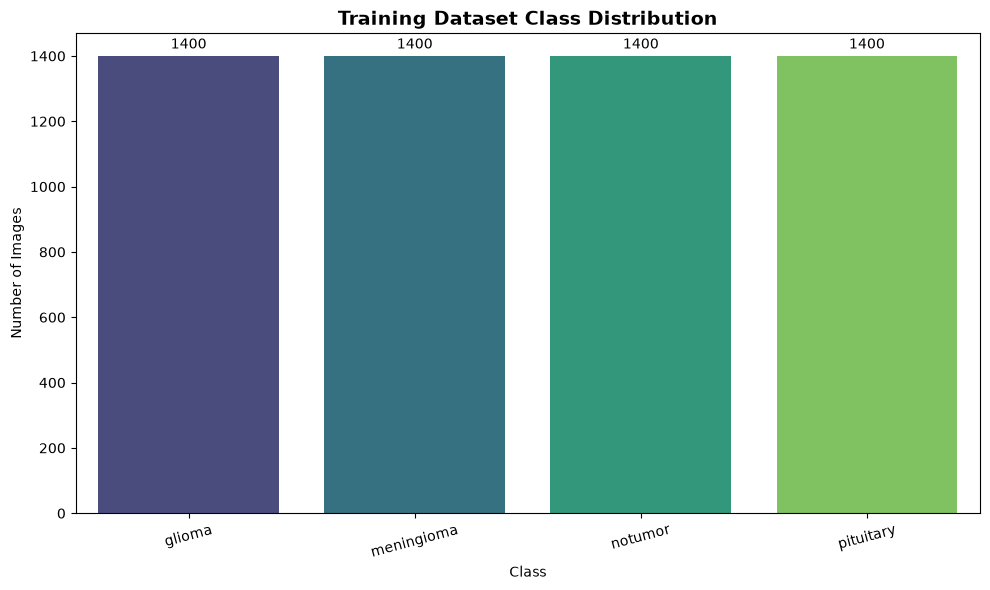

Figure saved to: ../results/figures/train_class_distribution.png


In [15]:

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=train_class_counts.index,
    y=train_class_counts.values,
    hue=train_class_counts.index,
    palette="viridis",
    legend=False,
)

plt.title("Training Dataset Class Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)

# نمایش تعداد دقیق بالای هر ستون
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.tight_layout()

output_path = FIGURES_DIR / "train_class_distribution.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {output_path}")


In [16]:
test_class_counts = (
    test_df["label"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)

print("Number of testing images per class:\n")

for class_name, count in test_class_counts.items():
    print(f"{class_name:<15}: {count:,}")

Number of testing images per class:

glioma         : 200
meningioma     : 200
notumor        : 200
pituitary      : 200


In [17]:
print("Dataset information:")
print("-" * 40)
print(f"Total images  : {len(test_df):,}")
print(f"Number of classes: {test_df['label'].nunique()}")
print(f"Classes       : {test_df['label'].unique().tolist()}")

display(test_df.sample(min(5, len(test_df)), random_state=SEED))


Dataset information:
----------------------------------------
Total images  : 800
Number of classes: 4
Classes       : ['notumor', 'glioma', 'meningioma', 'pituitary']


,filepath,label
114,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma
1599,/home/mehr/.cache/kagglehub/datasets/masoudnic...,pituitary
705,/home/mehr/.cache/kagglehub/datasets/masoudnic...,meningioma
186,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma
1206,/home/mehr/.cache/kagglehub/datasets/masoudnic...,pituitary


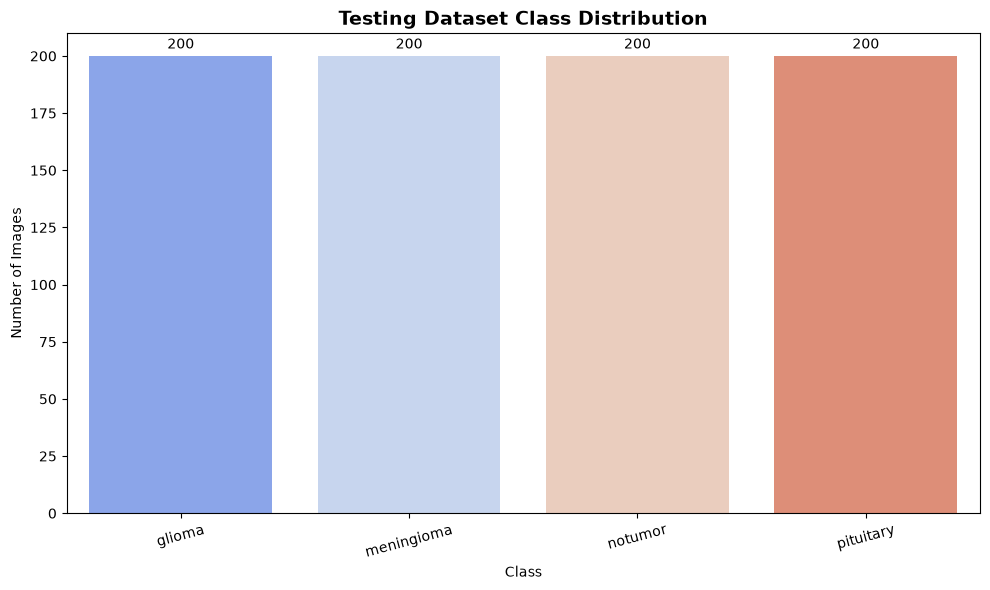

Figure saved to: ../results/figures/test_class_distribution.png


In [18]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=test_class_counts.index,
    y=test_class_counts.values,
    hue=test_class_counts.index,
    palette="coolwarm",
    legend=False,
)

plt.title("Testing Dataset Class Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)

# نمایش تعداد دقیق بالای هر ستون
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.tight_layout()

output_path = FIGURES_DIR / "test_class_distribution.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {output_path}")

In [19]:
valid_class_counts = (
    valid_df["label"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)

print("Number of validation images per class:\n")

for class_name, count in valid_class_counts.items():
    print(f"{class_name:<15}: {count:,}")

Number of validation images per class:

glioma         : 200
meningioma     : 200
notumor        : 200
pituitary      : 200


In [20]:
print("Dataset information:")
print("-" * 40)
print(f"Total images  : {len(valid_df):,}")
print(f"Number of classes: {valid_df['label'].nunique()}")
print(f"Classes       : {valid_df['label'].unique().tolist()}")

display(valid_df.sample(min(5, len(valid_df)), random_state=SEED))


Dataset information:
----------------------------------------
Total images  : 800
Number of classes: 4
Classes       : ['pituitary', 'meningioma', 'notumor', 'glioma']


,filepath,label
1331,/home/mehr/.cache/kagglehub/datasets/masoudnic...,pituitary
1307,/home/mehr/.cache/kagglehub/datasets/masoudnic...,pituitary
1074,/home/mehr/.cache/kagglehub/datasets/masoudnic...,notumor
849,/home/mehr/.cache/kagglehub/datasets/masoudnic...,notumor
640,/home/mehr/.cache/kagglehub/datasets/masoudnic...,meningioma


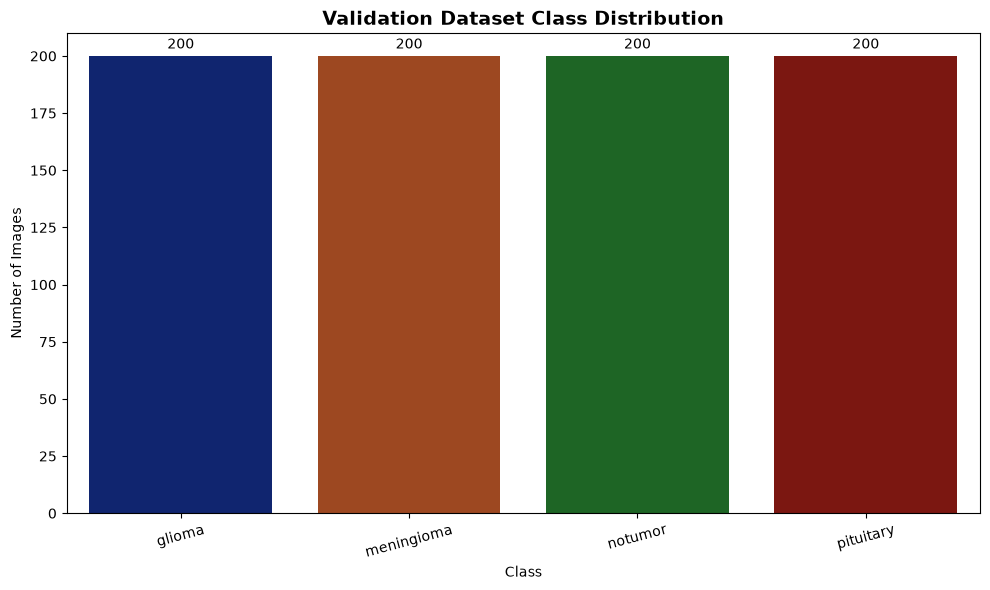

Figure saved to: ../results/figures/validation_class_distribution.png


In [21]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=valid_class_counts.index,
    y=valid_class_counts.values,
    hue=valid_class_counts.index,
    palette="dark",
    legend=False,
)

plt.title("Validation Dataset Class Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)

# نمایش تعداد دقیق بالای هر ستون
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.tight_layout()

output_path = FIGURES_DIR / "validation_class_distribution.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {output_path}")

# 5. Show Sample Image

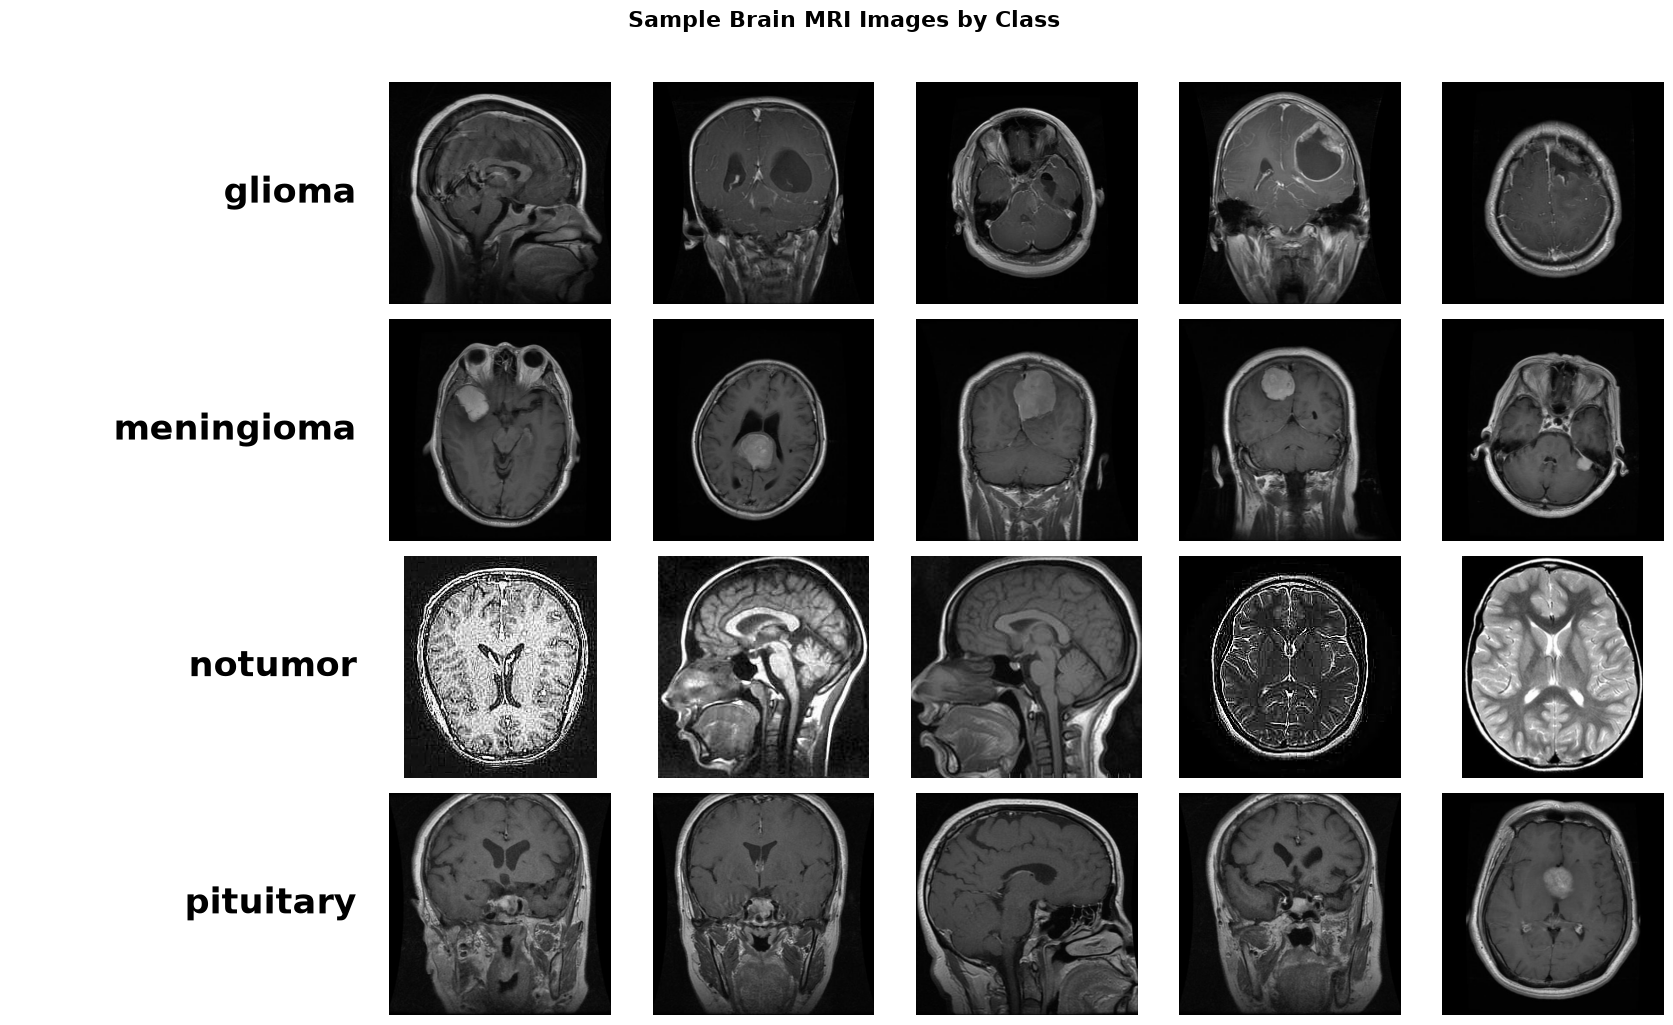

Figure saved to: ../results/figures/dataset_samples.png


In [22]:
SAMPLES_PER_CLASS = 5

fig, axes = plt.subplots(
    nrows=len(CLASS_NAMES),
    ncols=SAMPLES_PER_CLASS + 1,
    figsize=(17, 10),
    gridspec_kw={"width_ratios": [1.4] + [1] * SAMPLES_PER_CLASS},
)

for row, class_name in enumerate(CLASS_NAMES):
    label_ax = axes[row, 0]
    label_ax.text(
        0.98,
        0.5,
        class_name,
        ha="right",
        va="center",
        fontsize=25,
        fontweight="bold",
        wrap=True,
    )
    label_ax.axis("off")

    class_samples = (
        train_df[train_df["label"] == class_name]
        .sample(
            n=min(
                SAMPLES_PER_CLASS,
                (train_df["label"] == class_name).sum(),
            ),
            random_state=SEED,
        )
        .reset_index(drop=True)
    )

    for col in range(SAMPLES_PER_CLASS):
        ax = axes[row, col + 1]
        ax.axis("off")

        if col >= len(class_samples):
            continue

        image_path = class_samples.loc[col, "filepath"]

        with Image.open(image_path) as image:
            ax.imshow(image.convert("RGB"))

fig.suptitle(
    "Sample Brain MRI Images by Class",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()

samples_figure_path = FIGURES_DIR / "dataset_samples.png"
plt.savefig(samples_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {samples_figure_path}")



# 6. Saving DataFrames

In [23]:
DATAFRAMES_DIR = RESULTS_DIR / "dataframes"
DATAFRAMES_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(DATAFRAMES_DIR / "train_dataframe.csv", index=False)
valid_df.to_csv(DATAFRAMES_DIR / "validation_dataframe.csv", index=False)
test_df.to_csv(DATAFRAMES_DIR / "test_dataframe.csv", index=False)

print(f"DataFrames saved to: {DATAFRAMES_DIR}")

DataFrames saved to: ../results/dataframes
